# 模型评估实践：回归问题

本 Notebook 将演示回归任务中的核心评估指标与方法。由于网络原因，我们将使用本地的 **Kaggle 房价预测数据集** 进行实战演练。

## 涉及知识点
- 数据划分
- 常用指标：MAE, MSE, RMSE, MAPE, R2
- 残差分析
- 交叉验证

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 设置绘图风格
sns.set(style="whitegrid")
# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        plt.rcParams['font.sans-serif'] = fonts
        plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except Exception as e:
        print(f'字体设置失败: {e}')

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 1. 数据准备
读取本地的 Kaggle 房价数据集，并进行简单的预处理（仅选取数值特征并填充缺失值），以便聚焦于模型评估。

In [15]:
# 读取本地数据 (相对路径)
data_path = "../ch-04/06_综合案例_Kaggle房价预测/train.csv"
df = pd.read_csv(data_path)

print(f"原始数据维度: {df.shape}")

# 简单预处理：选取几个典型的数值特征用于演示
features = ['LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea', 'TotalBsmtSF', 'GarageCars']
target = 'SalePrice'

# 构建数据集
X = df[features].copy()
y = df[target]

# 填充缺失值 (简单的均值填充，确保代码可运行)
X = X.fillna(X.mean())

print(f"特征维度: {X.shape}")
print(f"目标变量示例 (房价): {y[:5].values}")

# 划分训练集与测试集 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

原始数据维度: (1460, 81)
特征维度: (1460, 6)
目标变量示例 (房价): [208500 181500 223500 140000 250000]
训练集大小: (1168, 6), 测试集大小: (292, 6)


## 2. 模型训练
这里我们使用简单的线性回归模型作为基准。

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 3. 评估指标计算
我们将计算 MAE, MSE, RMSE, MAPE, R2 等核心指标。

In [17]:
# 1. MAE (平均绝对误差)
mae = mean_absolute_error(y_test, y_pred)

# 2. MSE (均方误差)
mse = mean_squared_error(y_test, y_pred)

# 3. RMSE (均方根误差)
rmse = np.sqrt(mse)

# 4. MAPE (平均绝对百分比误差) - 手动计算
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# 5. R2 Score (决定系数)
r2 = r2_score(y_test, y_pred)

print("--- 回归评估指标 ---")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2:   {r2:.4f}")

--- 回归评估指标 ---
MAE:  24816.45
MSE:  1571829290.75
RMSE: 39646.30
MAPE: 14.90%
R2:   0.7951


## 4. 残差分析与可视化
通过可视化预测值与真实值的关系，以及残差分布，可以更直观地判断模型性能。

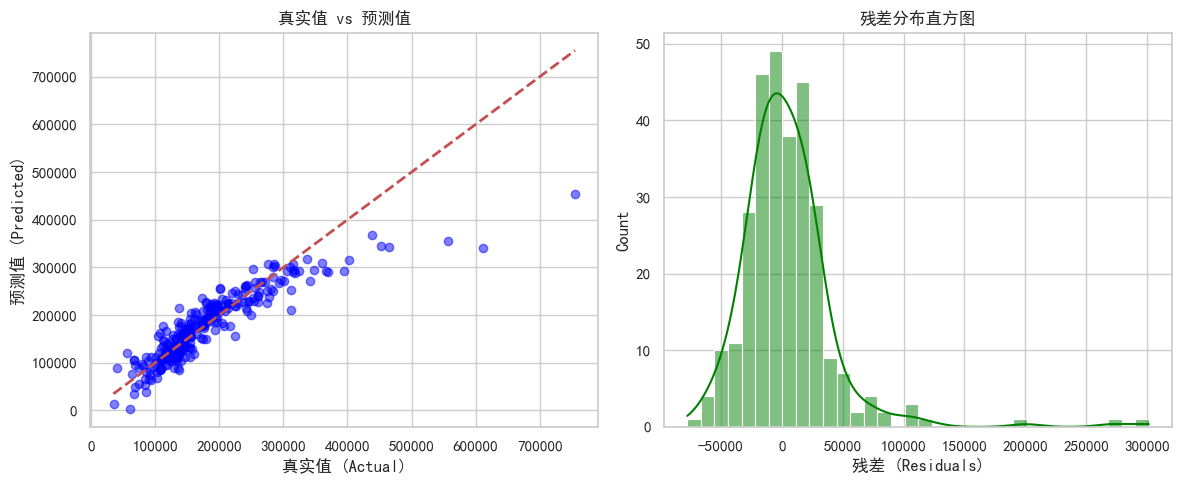

In [18]:
plt.figure(figsize=(12, 5))

# 子图1: 真实值 vs 预测值
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
# 绘制参考线
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('真实值 (Actual)')
plt.ylabel('预测值 (Predicted)')
plt.title('真实值 vs 预测值')

# 子图2: 残差分布
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='green')
plt.xlabel('残差 (Residuals)')
plt.title('残差分布直方图')

plt.tight_layout()
plt.show()

## 5. 交叉验证 (Cross Validation)
使用 K-Fold 交叉验证来获得更稳健的评估结果。

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score 默认使用 scoring 参数，回归通常用 'neg_mean_squared_error'
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

# 转换为 RMSE
cv_rmse = np.sqrt(-cv_scores)

print(f"5折交叉验证 RMSE: {cv_rmse}")
print(f"平均 RMSE: {cv_rmse.mean():.2f} (+/- {cv_rmse.std() * 2:.2f})")

5折交叉验证 RMSE: [39646.30235917 35594.36146946 53975.29349641 34331.00465877
 30505.20361152]
平均 RMSE: 38810.43 (+/- 16249.48)
